# Primary Productivity Absolute Relative Difference Analysis  
## Absolute relative difference analysis of the interim and legacy products
> History | Updated Nov 2025

## Objectives
Calculate the mean absolute relative difference (&Delta;<sub>rel</sub>) of the interim VIIRS netPP product (netPP<sub>VIIRS</sub>) and legacy MODIS netPP product (netPP<sub>MODIS</sub>) within a user-specified region for each month from a timeseries dependent on the user-specified VIIRS sensor.

For **VIIRS-SNPP**, the result will be a **120-month (10-year)** mean monthly timeseries of &Delta;<sup>netPP</sup> within your area of interest.

For **VIIRS-NOAA20**, the result will be a **60-month (5-year)** mean monthly timeseries of &Delta;<sup>netPP</sup> within your area of interest.

* &Delta;<sub>rel</sub> was calculated as the difference between VIIRS-SNPP (netPP<sub>VIIRS</sub>) and MODIS-Aqua netPP (netPP<sub>MODIS</sub>)  values divided by netPP<sub>MODIS</sub>. 
 
* Normalizing by netPP<sub>MODIS</sub> allow users to evaluate how much difference to expect in the netPP values used in their applications when switching to the interim product.  

### Steps:    
> * Download an area of monthly  &Delta;<sub>rel</sub> values from the ERDDAP server for each month from the timeseries.  
> * Mask the timeseries so that only data within a shapefile is retained.  
> * Calculate the mean values of &Delta;<sub>rel</sub> for each month. 
> * Visualized the timeseries and save the data.
> * Visualize the spatial variability in the timeseries monthly &Delta;<sup>lat/lon</sup> mean.

## Satellite Datasets:  
### Absolute Relative Difference
The absolute relative difference (&Delta;<sup>netPP</sup>) is calculated, for each pixel as follows:

$
\Large\Delta^{netPP} = \frac{netPP_{VIIRS} - netPP_{MODIS}}{netPP_{MODIS}}\
$  

Where:
* The difference between VIIRS and MODIS values for that pixel is divided by MODIS values.  


### Datasets Overview

We created the pixel-by-pixel unbiased relative difference (&Delta;<sup>netPP</sup>) for the globe for each monthy at a 9km resolution across two datasets:

1. **Relative Difference of Net Primary Productivity, VIIRS SNPP vs MODIS Aqua, 9Km, Monthly, 2013-2022, Global**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/netpp_delta_snpp_modis.graph

2. **Pixel by pixel Delta, VIIRS NOAA-20 minus MODIS Aqua**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/netpp_delta_noaa20_modis.graph

### Tutorial for this notebook

The VIIRS-SNPP - MODIS-Aqua dataset will be used in this notebook to generate a timeseries of monthly mean values of &Delta;<sup>netPP</sup>. We will access the data using the xr_open_ds() function below. The function requires:  
* The url of the ERDDAP server being use, in this case: https://coastwatch.pfeg.noaa.gov/wcn/erddap

* The ID of the dataset, in this case "netpp_delta_snpp_modis".

**To use the VIIRS-NOAA20 sensor instead,** set 'sensor = "noaa20"' in the code below.


In [1]:
# define sensor (either "snpp" or "noaa20")
sensor = "snpp"

# check that sensor is either snpp or noaa20
if sensor not in {"snpp", "noaa20"}:
    print("The variable sensor must have the value 'snpp' or 'noaa20'.")

# define time series based on sensor
if sensor == "noaa20":
    time_series = "2018-2022"
elif sensor == "snpp":
    time_series = "2013-2022"
else:
    times_series = "Unknown time series"

# set the url of the ERDDAP server
erddap_url = "https://coastwatch.pfeg.noaa.gov/wcn/erddap"

# set the dataset ID
erddap_id = f"netpp_delta_{sensor}_modis"

print(f"Dataset ID: {erddap_id}")

Dataset ID: netpp_delta_snpp_modis


## Shapefiles
#### Longhurst Marine Provinces  
The dataset represents the division of the world oceans into provinces as defined by Longhurst (1995; 1998; 2006). This division has been based on the prevailing role of physical forcing as a regulator of phytoplankton distribution. The Longhurst Marine Provinces dataset is available online (https://www.marineregions.org/downloads.php) and within the shapes folder associated with this repository.  

![](longhurst.png)

__For our example we will use the shapefile for the  "California Upwelling Coastal Province" (ProvCode: CCAL) within the Longhurst Marine Provinces classification__. 

## Resource requirements
-   **Jupyter Notebook**

-   **Python 3** with the modules included within the *Import packages*"* section below   

-   **Shapefile** of your area of interest
    * If you don't have shapefile, we will include some workarounds in the notebook.  
    
-   **Internet connection**

## Import packages

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np
import geopandas
import regionmask
import warnings
import os

warnings.filterwarnings("ignore")

## Create a few useful functions
### Function to make an Xarray dataset connection to an ERDDAP dataset

In [3]:
def xr_open_ds(
    e_id, e_source="https://coastwatch.pfeg.noaa.gov/wcn/erddap", dap="griddap"
):
    """
    Open a remote ERDDAP dataset as an Xarray dataset.

    Constructs the ERDDAP dataset URL using the provided dataset ID ('e_id'),
    server URL ('e_source'), and data access protocol ('dap'). Then it uses Xarray
    to open the dataset from the remote source.

    Args:
        e_id (str): ERDDAP dataset ID.
        e_source (str, optional): URL to ERDDAP server. Defaults to 'https://coastwatch.pfeg.noaa.gov/wcn/erddap'.
            You can change it to any ERDDAP server.
        dap (str, optional): The data access protocol type. Defaults to 'griddap' which is used for
        accessing gridded datasets.

    Returns:
        array: Xarray dataset object
    """
    # remove any trailing /
    e_source = e_source.rstrip("/")

    erddap_url = "/".join([e_source, dap, e_id])

    return xr.open_dataset(erddap_url)

### Function to spatially subset an Xarray dataset using latitude and longitude

In [4]:
def subset_ds(full_ds, var_name, bnds_dic):
    """Make a spatial subset a satellite dataset.

    Args:
        full_ds (array): 2D or 3D array with lat and lon coordinate variables
        var_name (str): Name of varaible to subset.
        bnds_dic (dic): Dictionary holding lat and lon max and min values

    Returns:
        array: Xarray dataset object
    """
    # correct for reversed latitude order on a dataset
    if full_ds.latitude[0] > full_ds.latitude[-1]:
        lt_first = bnds_dic["lat_max"]
        lt_last = bnds_dic["lat_min"]
    else:
        lt_first = bnds_dic["lat_min"]
        lt_last = bnds_dic["lat_max"]

    # subset the dataset
    return full_ds[var_name].sel(
        latitude=slice(lt_first, lt_last),
        longitude=slice(bnds_dic["lon_min"], bnds_dic["lon_max"]),
    )

## Load the Longhurst Provinces shapefiles into a geopandas dataframe
In this example, we'll use the shapefile for the  **California Upwelling Coastal Province** (ProvCode: CCAL) from the Longhurst Marine Provinces classification.

- This step also isolates the California Upwelling Coastal Province.

- To inspect the shapefile's position within the dataframe, uncomment the line: 'print(shapefiles[40:45])'

In [5]:
# create path to shapefile dataset
shape_path = os.path.join(
    "/Users/madisonrichardson/netpp/resources/Longhurst/Longhurst_world_v4_2010.shp"
)

# create a dataframe
shapefiles = geopandas.read_file(shape_path)

# uncomment net line to see the California Upwelling Coastal Province entry
# print(shapefiles[40:45])

ProvCode = "CCAL"
coastal_CA = shapefiles.loc[shapefiles["ProvCode"] == ProvCode]
coastal_CA

,ProvCode,ProvDescr,geometry
43,CCAL,Coastal - California Upwelling Coastal Province,"MULTIPOLYGON (((-110.5 24.5, -110.5 24.22013, ..."


## Create the regional mask for the California Upwelling Coastal Province
Display the region after creating it. 

<GeoAxes: >

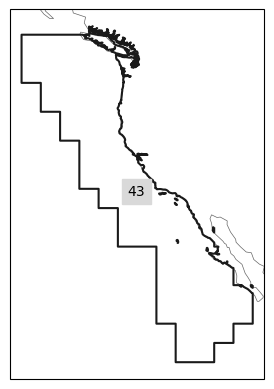

In [6]:
region = regionmask.from_geopandas(coastal_CA)
region.plot()

## Find the coordinates of the bounding box
* The bounding box is the smallest rectangle that will completely enclose the province.

* We will use the bounding box coordinates to subset the satellite data. 

In [7]:
gs_bnds = coastal_CA.bounds
gs_bnds

,minx,miny,maxx,maxy
43,-134.5,16.5,-110.5,51.383431


### To make it easier to use the subset_ds() function without a shapefile, put the bounding box coordinates in a Python dictionary.

In [8]:
geo_bnds = {}
geo_bnds["lon_min"] = gs_bnds.minx.item()
geo_bnds["lon_max"] = gs_bnds.maxx.item()
geo_bnds["lat_min"] = gs_bnds.miny.item()
geo_bnds["lat_max"] = gs_bnds.maxy.item()

## Open the &Delta;<sup>netPP</sup> dataset into an Xarray dataset object.
Pass the dataset ID and the ERDDAP server location to the xr_open_ds() function.  

* For details on xr_open_ds(), refer to the function's document string.

* **Reminder**: The erddap_id and erddap_url variables were set above.

In [9]:
ds = xr_open_ds(erddap_id, e_source=erddap_url)

ds

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 120, latitude: 2160, longitude: 4320)
Coordinates:
  * time       (time) datetime64[ns] 960B 2013-01-16T08:00:00 ... 2022-12-16T...
  * latitude   (latitude) float64 17kB 89.96 89.88 89.79 ... -89.88 -89.96
  * longitude  (longitude) float64 35kB -180.0 -179.9 -179.8 ... 179.9 180.0
Data variables:
    delta      (time, latitude, longitude) float32 4GB ...
Attributes: (12/44)
    acknowledgement:           This project was supported by the NOAA Office ...
    cdm_data_type:             Grid
    contributor:               Dale Robinson, Isaac Schroeder
    contributor_role:          development and project management, production...
    Conventions:               COARDS, CF-1.6, ACDD-1.3
    creator_name:              NOAA CoastWatch West Coast Node
    ...                        ...
    summary:                   The relative difference (rel_delta) between pr...
    time_coverage_end:         2022-12-16T08:00:00Z
    time_coverage_resolution:  P1M
    time_coverage_start:       2013-01-16T08:00:00Z
    title:                     Relative Difference of Net Primary Productivit...
    Westernmost_Easting:       -179.9583

### Note that the Data variable (above output) is named "delta".  
* We will need that name when using the subset_ds() function.

* Let's put the Data variable name into a variable.     

In [10]:
# Set erddap_var with data variable name
erddap_var = "delta"

## Subset the satellite data
* Pass the geo_bnds variable containing bounding box coordinates to the subset_ds() function.  

__The result will be a dataset that is:__  
* Spatially subsetted to the dimensions of the bounding box that contains all the months of the timeseries corresponding to the specified VIIRS sensor (either SNPP or NOAA20).

    - **120 months (10-years) for VIIRS-SNPP**

    - **60 months (5-years) for VIIRS-NOAA20**

In [11]:
subsetted_ds = subset_ds(ds, erddap_var, geo_bnds)

## Determine the approximate download size
Before downloading the data, it's helpful  to estimate the size of your data request to ERDDAP. 
* The data still has not been downloaded. That will happen later when an operation that needs the data is initiated. 

Depending on the installation, ERDDAP has maximum single download **limit of 2 Gigabytes.**  
* That seems large, but with satellite dataset large data volume adds up quickly.

The calculation for data download size estimate is below. 
* If the download size is nearing the single download limit, try splitting your download request into 2 or several separate requests and concatenate the data from the separate request.  

#### The request in this example is around 85 MB, well within the single download limit.

In [12]:
# get the number of longitude pixels along the longitude axis in the subsetted dataset
pixel_lon_axis = subsetted_ds.longitude.shape[0]


# get the number of latitude pixels along the latitude axis in the subsetted dataset
pixel_lon_axis = subsetted_ds.latitude.shape[0]


# set the memory size for a float data type in bytes
float_memory_size = 4


# get the number of timesteps in the subsetted dataset
no_of_timesteps = subsetted_ds.time.shape[0]

# calculate the approximate download size
download_size = (
    pixel_lon_axis * pixel_lon_axis * float_memory_size * no_of_timesteps
)

print("download_size", int(download_size) / 1000000, "Mb")

download_size 84.26928 Mb


## Create a mask and apply it to the data
__The result will be datasets that are:__  
* Masked to retain only the data within the shapefile. 

In [13]:
# Create the mask
mask = region.mask(subsetted_ds.longitude, subsetted_ds.latitude)

# Apply mask the the satellite data
delta_ds = subsetted_ds.where(mask == region.numbers[0])

# set workaround flag
wa_flag = False

## Workaround if you do not have a shapefile

If you don't have a shapefile, you can instead select a rectangular area define by a latitude and a longitude range that encompasses your area of interest.  

#### Please see [Appendix B: Steps for use without a shapfile](#no_shapefile) below.


## Calculate the monthly mean for each month to create a timeseries.
For each month of the timeseries (120-month for SNPP or 60-month for NOAA20) generate the mean &Delta;<sup>netPP</sup>.  
 
$
\Large\bar{\Delta}^{netPP}  = \frac{1}{N}\ \sum_{i=1}^{N} \Delta^{netPP}_{i}
$   

 * Where for each month N is the the number of pixels (<i>i</i>) within a month's grid with &Delta;<sup>netPP</sup> values. 

 Plot the timeseries on an XY graph.
* Uncomment the last three lines to save the graph and dataframe.

#### **Results for VIIRS-SNPP - MODIS-Aqua using shapefile** (workaround results will be different):
* <span style="text-decoration: overline;">&Delta;</span><sup>netPP</sup> values in general were between -0.05 and 0.10 over most of the timeseries, meaning netPP<sub>VIIRS</sub> was -5% to +10% of the value for netPP<sub>MODIS</sub>. 

* <span style="text-decoration: overline;">&Delta;</span><sup>netPP</sup> showed greater variability from 2022-2023.

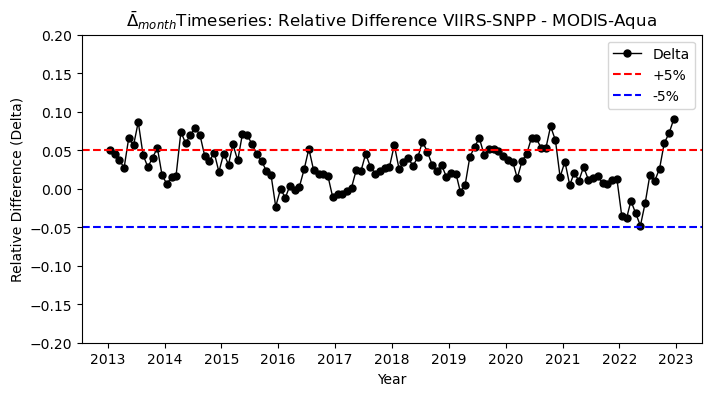

In [14]:
# generate the timeseries
delta_mean = delta_ds.mean(dim=["latitude", "longitude"])

# plot the results
plt.figure(figsize=(8, 4))
# plot the data
plt.plot_date(
    delta_ds.time,
    delta_mean,
    "o",
    markersize=5,
    label="Delta",
    c="black",
    linestyle="-",
    linewidth=1,
)

plt.axhline(y=0.05, color="r", linestyle="--", label="+5%")
plt.axhline(y=-0.05, color="b", linestyle="--", label="-5%")

plt.title(
    r"$\bar{\Delta}_{month}$"
    f"Timeseries: Relative Difference VIIRS-{sensor.upper()} - MODIS-Aqua"
)
plt.ylim([-0.2, 0.2])  # adjust this range to fit your area
plt.ylabel("Relative Difference (Delta)")
plt.xlabel("Year")
plt.legend()

# uncomment the next three lines to save the figure and the dataframe
# merged_df = delta_mean.to_dataframe()
# merged_df.to_csv('my_delta_timeseries.csv', index=False)
# plt.savefig('my_delta_timeseries.png')

## Visualize the spatial variability in the 10-year monthly &Delta; mean for VIIRS-SNPP - MODIS-Aqua

Plot the spatial variability in the 10-year monthly &Delta; mean on the selected Longhurst Province.
* Uncomment the last line to save the graph.

#### **Results for VIIRS-SNPP - MODIS-Aqua CCAL Region using shapefile** (workaround results will be different):

* Most of the region is positive, meaning VIIRS-SNPP values > MODIS-Aqua values. 

* The spots of higher difference are shown along the coastline where upwelling occurs.

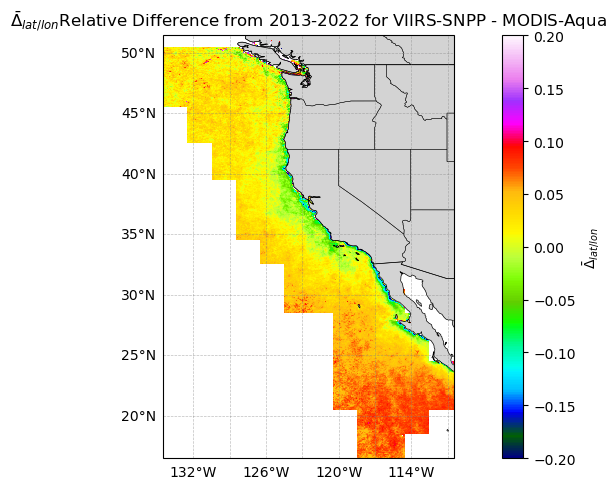

In [15]:
# calculate the 10-year mean across time for delta
mean_10year = delta_ds.mean(dim="time")

# set up figure with PlateCarree projection
fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# plot masked 10-year mean psi
pc = ax.pcolormesh(
    mean_10year.longitude,
    mean_10year.latitude,
    mean_10year,
    vmin=-0.2,
    vmax=0.2,
    cmap="gist_ncar",
    shading="auto",
    transform=ccrs.PlateCarree()
)

# add land and borders
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)  # <- U.S. state lines

# add gridlines with lat/lon labels
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False   # hide top labels
gl.right_labels = False # hide right labels
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

# set up title and colorbar
ax.set_title(
    r"$\bar{\Delta}_{lat/lon}$"
    f"Relative Difference from {time_series} for VIIRS-{sensor.upper()} - MODIS-Aqua",
    fontsize=12
)
fig.colorbar(pc, ax=ax, label=r"$\bar{\Delta}_{lat/lon}$")

plt.tight_layout()
plt.show()

# uncomment the next last line to save the figure
# plt.savefig('my_delta_spatial_variability_10yearmean.png')

## Appendix A: Visualize the unmasked and masked data on a map
The maps shows the full coverage of the bounding box and the masked area set by the shapefile fo CCAL.

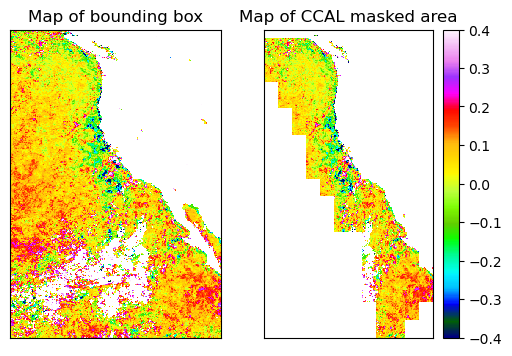

In [16]:
# if wa_flag is True, set 'plot_ds' to 'delta_ds', if not use 'subsetted_ds'
if wa_flag:
    plot_ds = delta_ds
else:
    plot_ds = subsetted_ds

# create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))

# customize the first subplot (ax1)
ax1.set_title("Map of bounding box")
ax1.set_yticks([])
ax1.set_xticks([])


# plot data on ax1 where plot_ds = subsetted_ds and reverse latitude order for correct orientation
ax1.pcolormesh(
    plot_ds[7].reindex(latitude=list(reversed(plot_ds.latitude))),
    vmin=-0.4,
    vmax=0.4,
    cmap="gist_ncar",
)


# customize the second subplot (ax2)
ax2.set_title("Map of CCAL masked area")
ax2.set_yticks([])
ax2.set_xticks([])


# plot data on ax2 where plot_ds = delta_ds and reverse latitude order for correct orientation
pc = ax2.pcolormesh(
    delta_ds[7].reindex(latitude=list(reversed(delta_ds.latitude))),
    vmin=-0.4,
    vmax=0.4,
    cmap="gist_ncar",
)


# add a color bar to the figure
fig.colorbar(pc)

## Appendix B: Steps for use without a shapefile
<a id='no_shapefile'></a>
### __Do not run this code if you have used a shapefile above!__
Use this method in place of cells tagged "Shapefile method".  

If you don't have a shapefile, you can just select a rectangular area that encompasses your area of interest. The area is define by a the maximum and minimum values of a latitude and a longitude range.   

__Steps__  
1. Load the geo_bnds dictionary with the minimum and maximum values for latitude and longitude the area of interest. 
* An area off the Oregon coast is used the example below:
    * Latitude range: 42.0&deg; to 46.0&deg; N  
    * Longitude range: -128.0&deg; to -124&deg; E
2. Proceed through the subsetting steps as listed below:
* Note that the masking steps have been omitted.
* The return from subset_ds() is labeled delta_ds.

In [17]:
geo_bnds = {}
geo_bnds["lon_min"] = -128.0
geo_bnds["lon_max"] = -124.0
geo_bnds["lat_min"] = 42.0
geo_bnds["lat_max"] = 46.0


# Change this code "subsetted_ds = subset_ds(ds, erddap_var, geo_bnds)" to:
delta_ds = subset_ds(ds, erddap_var, geo_bnds)

# set workaround flag
wa_flag = True

# Omit create the mask
# mask = region.mask(subsetted_ds.longitude, subsetted_ds.latitude)

# Omit apply mask the the satellite data
# delta_ds = subsetted_ds.where(mask == region.numbers[0])